# Gen11 Brake Calcs

In [37]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

try:
    import ipywidgets as widgets
    from IPython.display import display, Markdown
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

g = 9.81
print("g =", g)

g = 9.81


## Shared Vehicle Inputs

From **Gen 11 Mechanical VDR, 2025-26.docx**: $w=281\,kg, wb=2.30\,m, z_{cog}=47.30\,cm$

In [38]:
# general info
total_mass_kg = 281.0             
static_mass_front_kg = 183.0       
static_mass_rear_kg = 98.0         
wheelbase_length_m = 2.30        
cog_height_m = 0.473              

# straight line braking, all metric
initial_speed_mps = 30.0   
final_speed_mps = 0.0      
deceleration_mps2 = 9.81  

# downhill braking, metric
constant_speed_mps = 21.435568        
downhill_angle_deg = 2.28        # downhill slope angle in degrees
downhill_distance_m = 2650     # Downhill distance along the slope in meters

# DERIVED GEOMETRY (shared for both cases), in static cases
total_weight_N = total_mass_kg * g  
front_to_cog_distance_m = wheelbase_length_m * static_mass_rear_kg / total_mass_kg  # Horizontal distance from front axle to CoG in meters
rear_to_cog_distance_m = wheelbase_length_m - front_to_cog_distance_m  # Horizontal distance from rear axle to CoG in meters

# Print summary of vehicle parameters
print(f"Vehicle: {total_mass_kg} kg  L={wheelbase_length_m}m  h={cog_height_m:.4f}m  front_to_cog={front_to_cog_distance_m:.3f}m rear_to_cog={rear_to_cog_distance_m:.3f}m")
print(f"Case A: {initial_speed_mps}→{final_speed_mps} m/s @ {deceleration_mps2/g:.2f}g")
print(f"Case B: {constant_speed_mps} m/s @ {downhill_angle_deg}° for {downhill_distance_m/1000:.1f} km")

Vehicle: 281.0 kg  L=2.3m  h=0.4730m  front_to_cog=0.802m rear_to_cog=1.498m
Case A: 30.0→0.0 m/s @ 1.00g
Case B: 21.435568 m/s @ 2.28° for 2.6 km


## Case A — 1g Dynamic Braking

$F_1 = (W\cdot b_{rear} + m a h)/L$

In [39]:
# ── CASE A: Energy and Time Calculations ──
kinetic_energy_change_caseA_J = 0.5 * total_mass_kg * (initial_speed_mps**2 - final_speed_mps**2)  # Change in kinetic energy in Joules for Case A
braking_force_total_caseA_N = total_mass_kg * deceleration_mps2  # Total braking force required to achieve deceleration in Newtons for Case A
stopping_time_caseA_s = (initial_speed_mps - final_speed_mps) / deceleration_mps2  # Time to stop in seconds for Case A
average_power_caseA_W = kinetic_energy_change_caseA_J / stopping_time_caseA_s  # Average braking power in Watts for Case A

# ── CASE A: Normal Force Distribution ──
# Normal force on front axle during braking in Newtons for Case A
# Normal force on rear axle during braking in Newtons for Case A
normal_force_front_caseA_N = (total_weight_N * rear_to_cog_distance_m + total_mass_kg * deceleration_mps2 * cog_height_m) / wheelbase_length_m
normal_force_rear_caseA_N = total_weight_N - normal_force_front_caseA_N

# ── CASE A: Braking Force Distribution ──
# Braking force on front axle in Newtons for Case A
# Braking force on rear axle in Newtons for Case A
braking_force_front_caseA_N = braking_force_total_caseA_N * normal_force_front_caseA_N / total_weight_N  # Front braking force based on normal load distribution for Case A
braking_force_rear_caseA_N = braking_force_total_caseA_N - braking_force_front_caseA_N  # Rear braking force for Case A

print("--- Braking Force Distribution ---")
print(f"Front: {braking_force_front_caseA_N:,.0f} N ({braking_force_front_caseA_N/braking_force_total_caseA_N*100:.1f}%)")
print(f"Rear:  {braking_force_rear_caseA_N:,.0f} N ({braking_force_rear_caseA_N/braking_force_total_caseA_N*100:.1f}%)")
print(f"Total: {braking_force_total_caseA_N:,.0f} N")

print("--- Power (Heating) ---")
print(f"Front: {average_power_caseA_W * braking_force_front_caseA_N / braking_force_total_caseA_N / 1000:.1f} kW")
print(f"Rear:  {average_power_caseA_W * braking_force_rear_caseA_N / braking_force_total_caseA_N / 1000:.1f} kW")
print(f"Total: {average_power_caseA_W/1000:.1f} kW")

print("\n--- Per Wheel ---")
# Vehicle has 2 front wheels, 1 rear wheel
print(f"Front (each): {braking_force_front_caseA_N/2:,.0f} N, {average_power_caseA_W * braking_force_front_caseA_N / braking_force_total_caseA_N / 2 :.1f} W")
print(f"Rear (single): {braking_force_rear_caseA_N:,.0f} N, {average_power_caseA_W * braking_force_rear_caseA_N / braking_force_total_caseA_N :.1f} W")


--- Braking Force Distribution ---
Front: 2,362 N (85.7%)
Rear:  394 N (14.3%)
Total: 2,757 N
--- Power (Heating) ---
Front: 35.4 kW
Rear:  5.9 kW
Total: 41.3 kW

--- Per Wheel ---
Front (each): 1,181 N, 17716.0 W
Rear (single): 394 N, 5917.2 W


## Case B — Continuous Downhill (steady speed)

$N_1=(W\cos\theta\cdot b + W\sin\theta\cdot h)/L$

In [40]:
# ── CASE B: Angle and Component Calculations ──
downhill_angle_caseB_rad = math.radians(downhill_angle_deg)  # Convert downhill angle from degrees to radians for Case B
normal_weight_component_caseB_N = total_weight_N * math.cos(downhill_angle_caseB_rad)  # Normal weight component perpendicular to slope in Newtons for Case B
parallel_weight_component_caseB_N = total_weight_N * math.sin(downhill_angle_caseB_rad)  # Parallel weight component along slope in Newtons for Case B

# ── CASE B: Total Forces and Power ──
braking_force_total_caseB_N = parallel_weight_component_caseB_N  # Total braking force needed to maintain constant speed downhill equals parallel weight component for Case B
braking_power_total_caseB_W = braking_force_total_caseB_N * constant_speed_mps  # Total braking power in Watts (force * velocity) for Case B
descent_time_caseB_s = downhill_distance_m / constant_speed_mps  # Time to descend the slope in seconds for Case B

# ── CASE B: Normal Force Distribution ──
# Normal force on front axle during downhill braking for Case B
normal_force_front_caseB_N = (normal_weight_component_caseB_N * rear_to_cog_distance_m + parallel_weight_component_caseB_N * cog_height_m) / wheelbase_length_m
normal_force_rear_caseB_N = normal_weight_component_caseB_N - normal_force_front_caseB_N

# ── CASE B: Braking Force Distribution ──
braking_force_front_caseB_N = braking_force_total_caseB_N * normal_force_front_caseB_N / normal_weight_component_caseB_N  # Front braking force based on normal load distribution for Case B
braking_force_rear_caseB_N = braking_force_total_caseB_N - braking_force_front_caseB_N  # Rear braking force for Case B

# ── CASE B: Power Distribution ──
power_front_caseB_W = braking_power_total_caseB_W * normal_force_front_caseB_N / normal_weight_component_caseB_N  # Front braking power for Case B
power_rear_caseB_W = braking_power_total_caseB_W - power_front_caseB_W  # Rear braking power for Case B

print("--- Braking Force Distribution ---")
print(f"Front: {braking_force_front_caseB_N:,.0f} N ({braking_force_front_caseB_N/braking_force_total_caseB_N*100:.1f}%)")
print(f"Rear:  {braking_force_rear_caseB_N:,.0f} N ({braking_force_rear_caseB_N/braking_force_total_caseB_N*100:.1f}%)")
print(f"Total: {braking_force_total_caseB_N:,.0f} N")

print("--- Power (Heating) ---")
print(f"Front: {power_front_caseB_W/1000:.2f} kW ({power_front_caseB_W/braking_power_total_caseB_W*100:.1f}%)")
print(f"Rear:  {power_rear_caseB_W/1000:.2f} kW ({power_rear_caseB_W/braking_power_total_caseB_W*100:.1f}%)")
print(f"Total: {braking_power_total_caseB_W/1000:.2f} kW")

print("\n--- Per Wheel ---")
# Vehicle has 2 front wheels, 1 rear wheel
print(f"Front (each): {braking_force_front_caseB_N/2:,.0f} N, {power_front_caseB_W/2:.2f} W")
print(f"Rear (single): {braking_force_rear_caseB_N:,.0f} N, {power_rear_caseB_W:.2f} W")


--- Braking Force Distribution ---
Front: 72 N (65.9%)
Rear:  37 N (34.1%)
Total: 110 N
--- Power (Heating) ---
Front: 1.55 kW (65.9%)
Rear:  0.80 kW (34.1%)
Total: 2.35 kW

--- Per Wheel ---
Front (each): 36 N, 775.08 W
Rear (single): 37 N, 800.59 W


## Comparison Plots

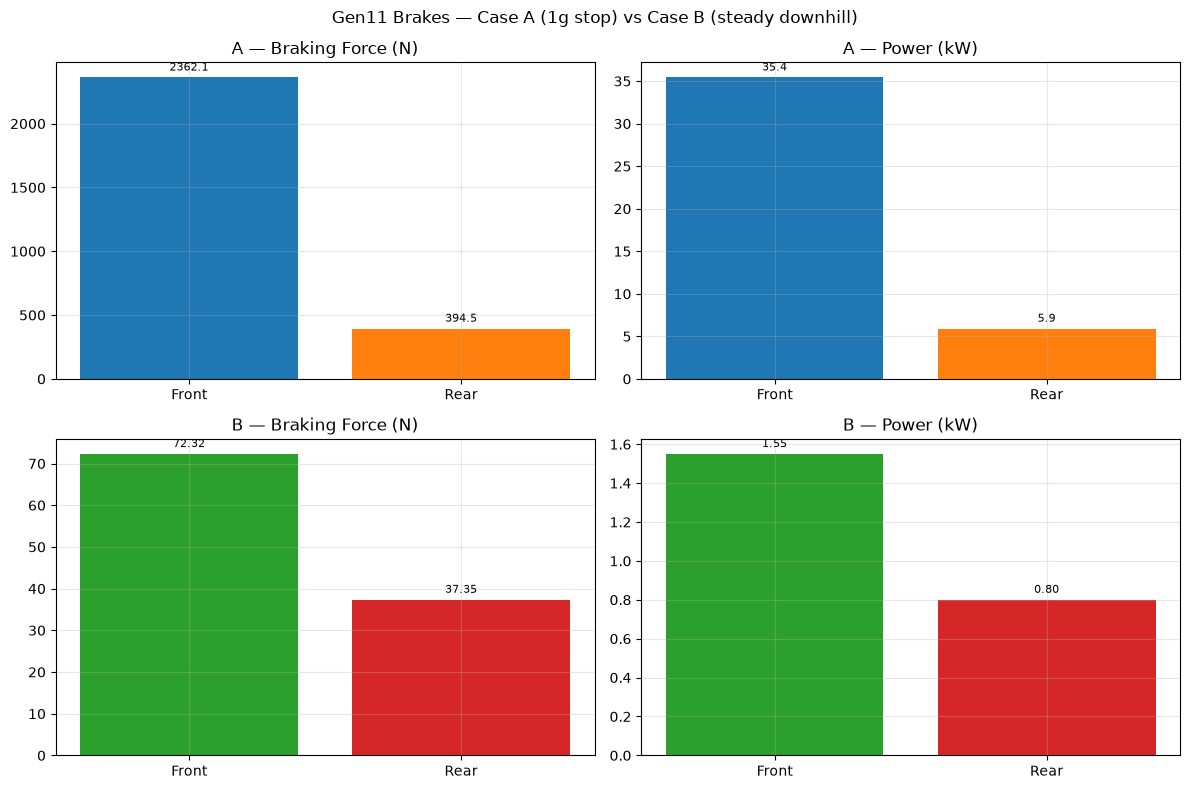

A front bias: 85.7%  |  B front bias: 65.9%
A avg power: 41.3 kW for 3.1s  |  B continuous: 2.35 kW for 2.1 min


In [41]:
labels = ['Front', 'Rear']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Row 1: Case A
axes[0,0].bar(labels, [braking_force_front_caseA_N, braking_force_rear_caseA_N], color=['#1f77b4','#ff7f0e'])
axes[0,0].set_title('A \u2014 Braking Force (N)')
axes[0,1].bar(labels, [average_power_caseA_W * braking_force_front_caseA_N / braking_force_total_caseA_N / 1000, average_power_caseA_W * braking_force_rear_caseA_N / braking_force_total_caseA_N / 1000], color=['#1f77b4','#ff7f0e'])
axes[0,1].set_title('A \u2014 Power (kW)')
for ax in axes[0]:
    for co in ax.containers:
        ax.bar_label(co, fmt='%.1f', padding=3, fontsize=8)

# Row 2: Case B
axes[1,0].bar(labels, [braking_force_front_caseB_N, braking_force_rear_caseB_N], color=['#2ca02c','#d62728'])
axes[1,0].set_title('B \u2014 Braking Force (N)')
axes[1,1].bar(labels, [power_front_caseB_W/1000, power_rear_caseB_W/1000], color=['#2ca02c','#d62728'])
axes[1,1].set_title('B \u2014 Power (kW)')
for ax in axes[1]:
    for co in ax.containers:
        ax.bar_label(co, fmt='%.2f', padding=3, fontsize=8)

fig.suptitle('Gen11 Brakes \u2014 Case A (1g stop) vs Case B (steady downhill)' , fontsize=12)
plt.tight_layout()
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
plt.show()

print(f"A front bias: {braking_force_front_caseA_N/braking_force_total_caseA_N*100:.1f}%  |  B front bias: {braking_force_front_caseB_N/braking_force_total_caseB_N*100:.1f}%")
print(f"A avg power: {average_power_caseA_W/1000:.1f} kW for {stopping_time_caseA_s:.1f}s  |  B continuous: {braking_power_total_caseB_W/1000:.2f} kW for {descent_time_caseB_s/60:.1f} min")

# Aliases for downstream cells expecting short names
B1_A = braking_force_front_caseA_N
B2_A = braking_force_rear_caseA_N
braking_force_total_A = braking_force_total_caseA_N
avg_power_A = average_power_caseA_W
t_stop = stopping_time_caseA_s
B1_B = braking_force_front_caseB_N
B2_B = braking_force_rear_caseB_N
Btot_B = braking_force_total_caseB_N
P1_B = power_front_caseB_W
P2_B = power_rear_caseB_W
Ptot_B = braking_power_total_caseB_W
t_desc = descent_time_caseB_s


In [42]:
# Dynamic SolidWorks summary table (updates when Case A/B/C rerun)
import math
from IPython.display import Markdown, display, clear_output

if "_SW_CASE_SUMMARY" not in globals():
    _SW_CASE_SUMMARY = {}


def _sw_gv(name, default):
    return globals()[name] if name in globals() else default


def _sw_h_any(v, D, Pr=0.707, floor=3.0):
    rho = _sw_gv("RHO", 1.225)
    mu = _sw_gv("MU", 1.81e-5)
    k_air = _sw_gv("K_AIR", 0.0263)
    if v <= 0:
        return max(0.0, floor)
    Re = rho * v * D / mu
    h = 0.664 * math.sqrt(Re) * Pr ** (1.0 / 3.0) * k_air / D
    return max(h, floor)


def _sw_fmt_scalar(value, decimals=2):
    txt = f"{value:.{decimals}f}"
    return txt.rstrip("0").rstrip(".")


def _sw_fmt_base(power_w, h_wm2k):
    return f"≈ {power_w:,.0f} W (P), {h_wm2k:.2f} W/m²K (h)"


def _sw_default_case_summaries():
    D_front = _sw_gv("D_FRONT", 0.254)
    D_rear = _sw_gv("D_REAR", 16.75 * 0.0254)
    Pr = _sw_gv("Pr", 0.707)
    h_floor = _sw_gv("h_floor", 3.0)

    v0_A = _sw_gv("initial_speed_mps", _sw_gv("initial_speed", 30.0))
    decel_A = _sw_gv("deceleration_mps2", _sw_gv("decel", 9.81))
    BfA = _sw_gv("B1_A", _sw_gv("braking_force_front_caseA_N", 2362.0)) / 2.0
    BrA = _sw_gv("B2_A", _sw_gv("braking_force_rear_caseA_N", 394.0))
    PfA = BfA * v0_A
    PrA = BrA * v0_A
    hfA = _sw_h_any(v0_A, D_front, Pr, h_floor)
    hrA = _sw_h_any(v0_A, D_rear, Pr, h_floor)
    tA = v0_A / decel_A if decel_A else 0.0

    speed_B = _sw_gv("constant_speed_mps", _sw_gv("constant_speed", 25.0))
    angle_B = _sw_gv("downhill_angle_deg", _sw_gv("downhill_angle", 15.0))
    distance_B = _sw_gv("downhill_distance_m", _sw_gv("downhill_distance", 2000.0))
    W = _sw_gv("total_weight_N", _sw_gv("total_weight", 281.0 * 9.81))
    b = _sw_gv("rear_to_cog_distance_m", _sw_gv("rear_to_cog", 1.498))
    hcg = _sw_gv("cog_height_m", _sw_gv("cog_height", 0.473))
    L = _sw_gv("wheelbase_length_m", _sw_gv("axle_distance", 2.30))
    th = math.radians(angle_B)
    Wn = W * math.cos(th)
    Wp = W * math.sin(th)
    N1 = (Wn * b + Wp * hcg) / L if L else 0.0
    N2 = Wn - N1
    BfB = Wp * N1 / Wn / 2.0 if Wn else 0.0
    BrB = Wp * N2 / Wn if Wn else 0.0
    PfB = BfB * speed_B
    PrB = BrB * speed_B
    hfB = _sw_h_any(speed_B, D_front, Pr, h_floor)
    hrB = _sw_h_any(speed_B, D_rear, Pr, h_floor)
    tB = distance_B / speed_B if speed_B else 0.0

    n_cycles = int(_sw_gv("n_cycles", 3))
    accel_g = _sw_gv("accel_g", 0.20)
    rest = _sw_gv("rest", 0.0)
    accel = accel_g * 9.81
    tC = n_cycles * (((v0_A / accel) if accel else 0.0) + tA + rest)

    return {
        "A": {
            "speed_mps": v0_A,
            "pf_peak_w": PfA,
            "pr_peak_w": PrA,
            "hf_peak": hfA,
            "hr_peak": hrA,
            "duration_s": tA,
            "decel_g": decel_A / 9.81 if 9.81 else 0.0,
        },
        "B": {
            "speed_mps": speed_B,
            "pf_peak_w": PfB,
            "pr_peak_w": PrB,
            "hf_peak": hfB,
            "hr_peak": hrB,
            "duration_s": tB,
            "angle_deg": angle_B,
        },
        "C": {
            "speed_mps": v0_A,
            "pf_peak_w": PfA,
            "pr_peak_w": PrA,
            "hf_peak": hfA,
            "hr_peak": hrA,
            "duration_s": tC,
            "accel_g": accel_g,
            "decel_g": decel_A / 9.81 if 9.81 else 0.0,
            "n_cycles": n_cycles,
        },
    }


def _sw_current_case_summaries():
    summaries = _sw_default_case_summaries()
    for key, payload in _SW_CASE_SUMMARY.items():
        summaries.setdefault(key, {}).update(payload)
    return summaries


if HAS_WIDGETS:
    _SW_SUMMARY_OUT = globals().get("_SW_SUMMARY_OUT", widgets.Output())
    globals()["_SW_SUMMARY_OUT"] = _SW_SUMMARY_OUT
    display(_SW_SUMMARY_OUT)
else:
    _SW_SUMMARY_OUT = None


def _render_sw_summary_table():
    D_front = _sw_gv("D_FRONT", 0.254)
    D_rear = _sw_gv("D_REAR", 16.75 * 0.0254)
    ratio = math.sqrt(D_front / D_rear)
    a, b, c = (_sw_current_case_summaries()[k] for k in ("A", "B", "C"))

    md = f"""## SolidWorks Transient Thermal Inputs — All 3 Cases (FRONT + REAR rotors)

**Front = one of the 2 front wheels** (per-rotor, not front-axle total). **Rear = the single rear wheel** (no divide by 2).

**Power: ONE shared normalized P curve** — `P_front(t) = B_front·v(t)` and `P_rear(t) = B_rear·v(t)`, so `P/P_peak = v/v0` is identical for both rotors. Paste the same 0–1 curve in both studies; type each study's OWN peak as its base magnitude.

**Convection: ONE shared normalized h curve** — `h(v,D) = K·sqrt(v)/sqrt(D)`, so `h/h_peak = sqrt(v/v0)` is identical for both diameters. Paste the same 0–1 curve in both studies; type each study's OWN peak as its base magnitude (front `D={D_front:.3f} m`, rear `D={D_rear:.5f} m`, `h_rear ≈ {ratio:.3f}× h_front`).

| Case | Speed profile | Base magnitude FRONT (peak/rotor) | Base magnitude REAR (peak/rotor) | Curve y | SolidWorks study |
|---|---|---|---|---|---|
| **A — 1g stop** | {_sw_fmt_scalar(a['speed_mps'], 2)} → 0 m/s | {_sw_fmt_base(a['pf_peak_w'], a['hf_peak'])} | {_sw_fmt_base(a['pr_peak_w'], a['hr_peak'])} | 0 → 1 | Transient {_sw_fmt_scalar(a['duration_s'], 2)} s — time curves (front study + rear study) |
| **B — Downhill** | {_sw_fmt_scalar(b['speed_mps'], 2)} m/s const | {_sw_fmt_base(b['pf_peak_w'], b['hf_peak'])} | {_sw_fmt_base(b['pr_peak_w'], b['hr_peak'])} | 1.0 flat | Steady-state (or flat curve, {_sw_fmt_scalar(b['duration_s'], 0)} s) — front value in front study, rear value in rear study |
| **C — Duty cycle** | {_sw_fmt_scalar(c['accel_g'], 2)}g accel / {_sw_fmt_scalar(c['decel_g'], 2)}g brake ×{int(c['n_cycles'])} | {_sw_fmt_base(c['pf_peak_w'], c['hf_peak'])} | {_sw_fmt_base(c['pr_peak_w'], c['hr_peak'])} | 0 → 1 pulses | Transient ≈ {_sw_fmt_scalar(c['duration_s'], 0)} s — time curves (front study + rear study) |


h correlation:
- laminar flat plate `Nu = 0.664·Re^0.5·Pr^(1/3)`, `h = Nu·k/D`, `Re = ρ·v·D/μ` (ρ=1.225, μ=1.81e-5, k=0.0263, Pr=0.707)
- **h_front peak** (D = {D_front:.3f} m) → {a['hf_peak']:.2f} W/m²K @ {_sw_fmt_scalar(a['speed_mps'], 2)} m/s, {b['hf_peak']:.2f} @ {_sw_fmt_scalar(b['speed_mps'], 2)} m/s
- **h_rear peak** (D = {D_rear:.5f} m) → ≈{a['hr_peak']:.2f} @ {_sw_fmt_scalar(a['speed_mps'], 2)} m/s, ≈{b['hr_peak']:.2f} @ {_sw_fmt_scalar(b['speed_mps'], 2)} m/s (≈{ratio:.3f}× front via 1/sqrt(D) scaling)
- A natural-convection floor (default 3 W/m²K) applies at standstill. Floor crossing differs slightly (front ~0.14 m/s, rear ~0.23 m/s) so shared-h norm differs only in the final ~0.1 s step — negligible for dt=0.1 s.

"""

    if HAS_WIDGETS:
        with _SW_SUMMARY_OUT:
            clear_output(wait=True)
            display(Markdown(md))
    else:
        display(Markdown(md))


_render_sw_summary_table()

Output()

In [43]:
# ====================================================================
#  SOLIDWORKS TRANSIENT TABLES - ALL 3 CASES (1xP shared + 1xh shared)
#  Front heat power is per rotor (1 of the 2 front wheels).
#  Rear heat power is per rotor (the single rear wheel - NO divide by 2).
#  P_front(t) = B_front*v(t), P_rear(t) = B_rear*v(t) -> SAME normalized
#  curve v/v0. Only ONE P column is stored (rear peak = front peak *
#  B_rear/B_front, printed in each case summary).
#  Convection: flat plate, h(v,D) = K*sqrt(v)/sqrt(D) -> SAME normalized
#  curve sqrt(v/v0) for both diameters. Only ONE h column is stored
#  (reference = front D; rear peak = front peak * sqrt(D_front/D_rear),
#  printed in each case summary).
#    D_FRONT = 0.254 m (10 in), D_REAR = 0.42545 m (16.75 in).
#  Floor caveat: absolute floor 3 W/m2K hits at slightly different v
#  (front ~0.14, rear ~0.23 m/s), so shared-h norm differs only in the
#  final sub-0.2 m/s step -- negligible for dt=0.1 s.
# ====================================================================
import math
import matplotlib.pyplot as plt

# -- air properties (from Avg h Calculation.xlsx, Flat Plate sheet) --
RHO   = 1.225     # kg/m^3
MU    = 1.81e-5   # kg/(m*s)
K_AIR = 0.0263    # W/m-K
D_FRONT = 0.254     # m front rotor OD (10 in)
D_REAR  = 16.75 * 0.0254  # m rear rotor OD (16.75 in) = 0.42545
D_REF = D_FRONT   # kept for backwards compat
H_SCALE_REAR = (D_FRONT / D_REAR) ** 0.5  # ~= 0.7727, h_rear = h_front * scale (above floor)

def _gv(name, default):
    # grab a variable from the notebook namespace if it exists
    return globals()[name] if name in globals() else default

def h_flat_plate(v, D=D_FRONT, Pr=0.707):
    # laminar flat plate: Nu = 0.664 Re^0.5 Pr^(1/3) -> 43.98 @ 30 m/s (D=.254, Pr=.707)
    if v <= 0:
        return 0.0
    Re = RHO * v * D / MU
    return 0.664 * math.sqrt(Re) * Pr ** (1.0 / 3.0) * K_AIR / D

def _h_any(v, D, Pr, floor):
    # flat-plate h with a natural-convection floor near standstill
    return max(h_flat_plate(v, D, Pr), floor)

def _trapz(ys, ts):
    return sum((ys[i] + ys[i + 1]) * 0.5 * (ts[i + 1] - ts[i]) for i in range(len(ts) - 1))

# -- per-curve 2-column export: rows = (t, v, P_ref_W, h_ref) --
# P_ref = B_front_per_rotor * v. h_ref = front-D h(v) (reference).
# Rear curves share the SAME normalized shape; use rear peaks below.
_CURVE_OPTS = {"P shared (front+rear)": (2, "{:.0f}", "W"),
               "h shared (front+rear)": (3, "{:.4f}", "W/m2K")}
_LAST_ROWS = {}   # case key -> latest rows (feeds the copy boxes)
_CURVE_CB = {}    # case key -> callback(rows) wired up in the widgets section
_SW_CASE_SUMMARY = globals().get("_SW_CASE_SUMMARY", {})


def _update_sw_summary(case_key, summary):
    _SW_CASE_SUMMARY[case_key] = summary
    _render = globals().get("_render_sw_summary_table")
    if callable(_render):
        _render()

def _print_table(rows):
    # combined reference view (only used when ipywidgets is unavailable)
    P_peak = max(r[2] for r in rows)
    h_peak = max(r[3] for r in rows)
    hdr = (f"{'t [s]':>7}  {'v [m/s]':>8}  {'P ref [W]':>12}  {'h ref':>8}  "
           f"{'P norm':>8}  {'h norm':>8}")
    print(hdr)
    print("-" * len(hdr))
    for t, v, p, h in rows:
        print(f"{t:>7.2f}  {v:>8.2f}  {p:>12,.0f}  {h:>8.2f}  "
              f"{p / P_peak if P_peak else 0:>8.4f}  {h / h_peak if h_peak else 0:>8.4f}")
    print("-" * len(hdr))

def _plot_ph(rows, title):
    ts = [r[0] for r in rows]
    fig, (axP, axH) = plt.subplots(1, 2, figsize=(11, 4))
    axP.plot(ts, [r[2] for r in rows], "b-", label="P shared (front+rear norm)")
    axP.set_xlabel("t [s]")
    axP.set_ylabel("P ref per rotor [W]")
    axP.set_title("Heat power (shared norm)")
    axP.grid(alpha=0.3)
    axP.legend(fontsize=8)
    axH.plot(ts, [r[3] for r in rows], "r-", label="h shared (front+rear norm)")
    axH.set_xlabel("t [s]")
    axH.set_ylabel("h ref [W/m2K]")
    axH.set_title("Convection (shared norm)")
    axH.grid(alpha=0.3)
    axH.legend(fontsize=8)
    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    plt.show()

# --------------------------------------------------------------------
# CASE A - 1g stop: P(t) and h(t) step down together (single P + single h)
# --------------------------------------------------------------------
def run_caseA(B_rotor=None, B_rear=None, v0=30.0, decel=9.81, Pr=0.707, dt=0.1, h_floor=3.0,
              D_front=D_FRONT, D_rear=D_REAR):
    B_rotor = B_rotor if B_rotor is not None else _gv("B1_A", 2362.0) / 2.0   # per FRONT rotor (2 front wheels)
    B_rear = B_rear if B_rear is not None else _gv("B2_A", 394.0)             # per REAR rotor (single rear wheel, no divide)
    t_stop = v0 / decel
    times = [round(i * dt, 10) for i in range(int(math.ceil(t_stop / dt)))]
    if abs(times[-1] - t_stop) > 1e-9:
        times.append(round(t_stop, 10))
    rows = []
    for t in times:
        v = max(v0 - decel * t, 0.0)
        rows.append((t, v, B_rotor * v, _h_any(v, D_front, Pr, h_floor)))
    print(f"CASE A - 1g stop: {v0:.1f} -> 0 m/s @ {decel:.2f} m/s2 ({t_stop:.2f} s)   "
          f"B per front rotor = {B_rotor:,.0f} N   |   B per rear rotor = {B_rear:,.0f} N")
    if not HAS_WIDGETS:
        _print_table(rows)
    Ef = _trapz([r[2] for r in rows], [r[0] for r in rows])
    Pf_peak = rows[0][2]
    Pr_peak = Pf_peak * (B_rear / B_rotor) if B_rotor else 0.0
    Er = Ef * (B_rear / B_rotor) if B_rotor else 0.0
    hf_peak = rows[0][3]
    hr_peak = _h_any(v0, D_rear, Pr, h_floor)
    _update_sw_summary("A", {
        "speed_mps": v0,
        "pf_peak_w": Pf_peak,
        "pr_peak_w": Pr_peak,
        "hf_peak": hf_peak,
        "hr_peak": hr_peak,
        "duration_s": t_stop,
        "decel_g": decel / 9.81 if 9.81 else 0.0,
    })
    print(f"peak P front = {Pf_peak:,.1f} W/rotor   |   time-avg = {Ef / t_stop:,.1f} W   |   "
          f"energy/front-rotor = {Ef:,.0f} J")
    print(f"peak P rear  = {Pr_peak:,.1f} W/rotor   |   time-avg = {Er / t_stop:,.1f} W   |   "
          f"energy/rear-rotor  = {Er:,.0f} J   (same normalized curve as front)")
    print(f"SolidWorks base magnitudes:  Heat Power FRONT = {Pf_peak:,.1f} W   |   "
          f"Heat Power REAR = {Pr_peak:,.1f} W   |   Convection FRONT = {hf_peak:.4f} W/m2K   |   "
          f"Convection REAR = {hr_peak:.4f} W/m2K   (same normalized h curve)")
    _plot_ph(rows, f"Case A - {v0:.0f} -> 0 m/s @ {decel:.2f} m/s2 (1xP + 1xh shared)")
    _cb = _CURVE_CB.get("A")
    if _cb is not None:
        _cb(rows)
    return rows

# --------------------------------------------------------------------
# CASE B - steady downhill: constant speed -> constant P and h (1xP + 1xh)
# --------------------------------------------------------------------
def run_caseB(speed=None, angle=None, distance=None, Pr=0.707, h_floor=3.0,
              D_front=D_FRONT, D_rear=D_REAR):
    speed = speed if speed is not None else _gv("constant_speed_mps", _gv("constant_speed", 25.0))
    angle = angle if angle is not None else _gv("downhill_angle_deg", _gv("downhill_angle", 15.0))
    distance = distance if distance is not None else _gv("downhill_distance_m", _gv("downhill_distance", 2000.0))
    W = _gv("total_weight_N", _gv("total_weight", 281.0 * 9.81))
    b = _gv("rear_to_cog_distance_m", _gv("rear_to_cog", 1.498))
    hcg = _gv("cog_height_m", _gv("cog_height", 0.473))
    L = _gv("wheelbase_length_m", _gv("axle_distance", 2.30))
    th = math.radians(angle)
    Wn = W * math.cos(th)
    Wp = W * math.sin(th)
    N1 = (Wn * b + Wp * hcg) / L
    N2 = Wn - N1
    Bf_rotor = Wp * N1 / Wn / 2.0                 # braking force per FRONT rotor (2 front wheels)
    Br_rotor = Wp * N2 / Wn                       # braking force per REAR rotor (single wheel, no divide)
    Pf_rotor = Bf_rotor * speed                   # heat power per front rotor
    Pr_rotor = Br_rotor * speed                   # heat power per rear rotor
    t_desc = distance / speed
    hf = _h_any(speed, D_front, Pr, h_floor)
    hr = _h_any(speed, D_rear, Pr, h_floor)
    rows = [(0.0, speed, Pf_rotor, hf), (round(t_desc, 4), speed, Pf_rotor, hf)]
    _update_sw_summary("B", {
        "speed_mps": speed,
        "pf_peak_w": Pf_rotor,
        "pr_peak_w": Pr_rotor,
        "hf_peak": hf,
        "hr_peak": hr,
        "duration_s": t_desc,
        "angle_deg": angle,
    })
    print(f"CASE B - steady downhill: {speed:.1f} m/s @ {angle:.1f} deg for {t_desc:.0f} s   "
          f"(front axle bias {N1 / Wn * 100:.1f}%)   constant -> Steady-State study or flat time curve")
    if not HAS_WIDGETS:
        _print_table(rows)
    print(f"P FRONT = {Pf_rotor:,.1f} W/rotor   |   B = {Bf_rotor:,.1f} N   |   "
          f"energy/front-rotor = {Pf_rotor * t_desc:,.0f} J")
    print(f"P REAR  = {Pr_rotor:,.1f} W/rotor   |   B = {Br_rotor:,.1f} N   |   "
          f"energy/rear-rotor  = {Pr_rotor * t_desc:,.0f} J   (same normalized curve as front)")
    print(f"SolidWorks base magnitudes:  Heat Power FRONT = {Pf_rotor:,.1f} W   |   "
          f"Heat Power REAR = {Pr_rotor:,.1f} W   |   Convection FRONT = {hf:.4f} W/m2K   |   "
          f"Convection REAR = {hr:.4f} W/m2K   (same normalized h curve)")
    _cb = _CURVE_CB.get("B")
    if _cb is not None:
        _cb(rows)
    return rows

# --------------------------------------------------------------------
# CASE C - repeated duty cycle: 0.2g accel (no heat) / 1g brake pulses (1xP + 1xh)
# --------------------------------------------------------------------
def run_caseC(n_cycles=3, accel_g=0.20, v0=30.0, decel=9.81, rest=0.0,
              Pr=0.707, dt=0.1, h_floor=3.0, B_rotor=None, B_rear=None,
              D_front=D_FRONT, D_rear=D_REAR):
    B_rotor = B_rotor if B_rotor is not None else _gv("B1_A", 2362.0) / 2.0
    B_rear = B_rear if B_rear is not None else _gv("B2_A", 394.0)
    accel = accel_g * 9.81
    t_a = v0 / accel
    t_b = v0 / decel
    cycle = t_a + t_b + rest
    rows = []
    for c in range(n_cycles):
        t0 = round(c * cycle, 10)
        # accelerate 0 -> v0: no braking heat, h follows the rising speed
        for i in range(int(math.ceil(t_a / dt))):
            t = round(t0 + i * dt, 10)
            v = accel * (t - t0)
            rows.append((t, v, 0.0, _h_any(v, D_front, Pr, h_floor)))
        # brake v0 -> 0: P and h decay together
        for i in range(int(math.ceil(t_b / dt))):
            t = round(t0 + t_a + i * dt, 10)
            v = max(v0 - decel * i * dt, 0.0)
            rows.append((t, v, B_rotor * v, _h_any(v, D_front, Pr, h_floor)))
        if abs(rows[-1][0] - round(t0 + t_a + t_b, 10)) > 1e-9:
            rows.append((round(t0 + t_a + t_b, 10), 0.0, 0.0, h_floor))
        # optional standstill rest between cycles
        if rest > 0:
            for i in range(1, int(round(rest / dt)) + 1):
                if i * dt <= rest + 1e-9:
                    t = round(t0 + t_a + t_b + i * dt, 10)
                    rows.append((t, 0.0, 0.0, h_floor))
    total = n_cycles * cycle
    print(f"CASE C - repeated duty cycle: {n_cycles} x [accel {accel_g:.2f}g -> {v0:.0f} m/s in {t_a:.2f} s "
          f"+ brake @ {decel:.2f} m/s2 in {t_b:.2f} s]   rest = {rest:.0f} s   total = {total:.2f} s")
    if not HAS_WIDGETS:
        _print_table(rows)
    Ef = n_cycles * B_rotor * v0 ** 2 / (2.0 * decel)     # exact (brake pulses only)
    Er = n_cycles * B_rear * v0 ** 2 / (2.0 * decel)
    Pf_peak = max(r[2] for r in rows)
    Pr_peak = Pf_peak * (B_rear / B_rotor) if B_rotor else 0.0
    hf_peak = max(r[3] for r in rows)
    hr_peak = _h_any(v0, D_rear, Pr, h_floor)
    _update_sw_summary("C", {
        "speed_mps": v0,
        "pf_peak_w": Pf_peak,
        "pr_peak_w": Pr_peak,
        "hf_peak": hf_peak,
        "hr_peak": hr_peak,
        "duration_s": total,
        "accel_g": accel_g,
        "decel_g": decel / 9.81 if 9.81 else 0.0,
        "n_cycles": n_cycles,
    })
    print(f"peak P front = {Pf_peak:,.1f} W/rotor   |   energy/front-rotor = {Ef:,.0f} J   |   "
          f"avg P = {Ef / total:,.1f} W")
    print(f"peak P rear  = {Pr_peak:,.1f} W/rotor   |   energy/rear-rotor  = {Er:,.0f} J   |   "
          f"avg P = {Er / total:,.1f} W   (same normalized curve as front)")
    print(f"SolidWorks base magnitudes:  Heat Power FRONT = {Pf_peak:,.1f} W   |   "
          f"Heat Power REAR = {Pr_peak:,.1f} W   |   Convection FRONT = {hf_peak:.4f} W/m2K   |   "
          f"Convection REAR = {hr_peak:.4f} W/m2K   (same normalized h curve)")
    _plot_ph(rows, f"Case C - {n_cycles} cycles ({accel_g:.2f}g accel / {decel / 9.81:.2f}g brake)")
    _cb = _CURVE_CB.get("C")
    if _cb is not None:
        _cb(rows)
    return rows

# --------------------------------------------------------------------
# interactive controls (falls back to combined reference tables)
# --------------------------------------------------------------------
if HAS_WIDGETS:
    def _make_curve_ui(key):
        # dropdown + read-only box showing ONE 2-column (time, value) table at a time
        dd = widgets.Dropdown(options=list(_CURVE_OPTS), value="P shared (front+rear)", description="curve:")
        ta = widgets.Textarea(layout=widgets.Layout(width="420px", height="300px"),
                              style={"font_family": "Consolas, monospace"})
        hint = widgets.HTML("<i>normalized 0&ndash;1 curve &rarr; click in the box &rarr; Ctrl+A &rarr; Ctrl+C &rarr; "
                            "paste as Time Curve; set base magnitude = peak from the summary above</i>")
        def _fill():
            col, fmt, _unit = _CURVE_OPTS[dd.value]
            rows = _LAST_ROWS.get(key, [])
            peak = max((r[col] for r in rows), default=0.0)
            # normalized 0-1 curve: y = value / peak -> SolidWorks multiplies
            # by the base magnitude printed in the case summary
            ta.value = "\n".join(f"{r[0]:.2f}\t{r[col] / peak:.4f}" if peak else f"{r[0]:.2f}\t0.0000" for r in rows)
        def _on_dd(change):
            if change.get("type") == "change" and change.get("name") == "value":
                _fill()
        def _on_rows(rows):
            _LAST_ROWS[key] = rows
            _fill()
        dd.observe(_on_dd)
        _CURVE_CB[key] = _on_rows
        _fill()   # rows were already stored by the pre-registered callback -> fill now
        return widgets.VBox([dd, hint, ta])
    _a_w = {
        "B_rotor": widgets.FloatSlider(value=float(_gv("B1_A", 2362.0)) / 2.0, min=250.0, max=3000.0, step=5.0, description="B front/rotor [N]", continuous_update=False),
        "B_rear": widgets.FloatSlider(value=float(_gv("B2_A", 394.0)), min=50.0, max=1500.0, step=5.0, description="B rear rotor [N]", continuous_update=False),
        "v0":      widgets.FloatSlider(value=float(_gv("initial_speed", 30.0)), min=1.0, max=60.0, step=0.5, description="v0 [m/s]", continuous_update=False),
        "decel":   widgets.FloatSlider(value=float(_gv("decel", 9.81)), min=1.0, max=15.0, step=0.01, description="decel [m/s2]", readout_format=".2f", continuous_update=False),
        "Pr":      widgets.FloatSlider(value=0.707, min=0.60, max=0.75, step=0.001, description="Pr", readout_format=".3f", continuous_update=False),
        "dt":      widgets.FloatSlider(value=0.1, min=0.02, max=0.50, step=0.01, description="dt [s]", readout_format=".2f", continuous_update=False),
        "h_floor": widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description="h floor", readout_format=".1f", continuous_update=False),
    }
    # register the curve callback BEFORE interactive_output's initial run so the
    # copy boxes are filled on the first pass (no empty box until a slider moves)
    _CURVE_CB["A"] = lambda rows: _LAST_ROWS.update(A=rows)
    _a_out = widgets.interactive_output(run_caseA, _a_w)
    display(Markdown("### Case A - 1g stop (per rotor: 1 front of 2 + single rear)"), _a_out, _make_curve_ui("A"))
    _b_w = {
        "speed":    widgets.FloatSlider(value=float(_gv("constant_speed_mps", _gv("constant_speed", 25.0))), min=5.0, max=40.0, step=0.5, description="speed [m/s]", continuous_update=False),
        "angle":    widgets.FloatSlider(value=float(_gv("downhill_angle_deg", _gv("downhill_angle", 15.0))), min=0.0, max=30.0, step=0.1, description="angle [deg]", continuous_update=False),
        "distance": widgets.FloatSlider(value=float(_gv("downhill_distance_m", _gv("downhill_distance", 2000.0))), min=100.0, max=5000.0, step=50.0, description="distance [m]", continuous_update=False),
        "Pr":       widgets.FloatSlider(value=0.707, min=0.60, max=0.75, step=0.001, description="Pr", readout_format=".3f", continuous_update=False),
        "h_floor":  widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description="h floor", readout_format=".1f", continuous_update=False),
    }
    _CURVE_CB["B"] = lambda rows: _LAST_ROWS.update(B=rows)
    _b_out = widgets.interactive_output(run_caseB, _b_w)
    display(Markdown("### Case B - steady downhill (per rotor: 1 front of 2 + single rear, constant)"), _b_out, _make_curve_ui("B"))
    _c_w = {
        "B_rotor": widgets.FloatSlider(value=float(_gv("B1_A", 2362.0)) / 2.0, min=250.0, max=3000.0, step=5.0, description="B front/rotor [N]", continuous_update=False),
        "B_rear": widgets.FloatSlider(value=float(_gv("B2_A", 394.0)), min=50.0, max=1500.0, step=5.0, description="B rear rotor [N]", continuous_update=False),
        "n_cycles": widgets.IntSlider(value=3, min=1, max=10, step=1, description="cycles", continuous_update=False),
        "accel_g":  widgets.FloatSlider(value=0.20, min=0.05, max=0.50, step=0.01, description="accel [g]", readout_format=".2f", continuous_update=False),
        "v0":       widgets.FloatSlider(value=30.0, min=10.0, max=60.0, step=1.0, description="v0 [m/s]", continuous_update=False),
        "decel":    widgets.FloatSlider(value=9.81, min=5.0, max=15.0, step=0.01, description="decel [m/s2]", readout_format=".2f", continuous_update=False),
        "rest":     widgets.FloatSlider(value=0.0, min=0.0, max=30.0, step=1.0, description="rest [s]", readout_format=".0f", continuous_update=False),
        "Pr":       widgets.FloatSlider(value=0.707, min=0.60, max=0.75, step=0.001, description="Pr", readout_format=".3f", continuous_update=False),
        "dt":       widgets.FloatSlider(value=0.1, min=0.05, max=0.50, step=0.05, description="dt [s]", readout_format=".2f", continuous_update=False),
        "h_floor":  widgets.FloatSlider(value=3.0, min=0.0, max=10.0, step=0.5, description="h floor", readout_format=".1f", continuous_update=False),
    }
    _CURVE_CB["C"] = lambda rows: _LAST_ROWS.update(C=rows)
    _c_out = widgets.interactive_output(run_caseC, _c_w)
    display(Markdown("### Case C - repeated duty cycle (per rotor: 1 front of 2 + single rear)"), _c_out, _make_curve_ui("C"))
else:
    run_caseA()
    run_caseB()
    run_caseC()


### Case A - 1g stop (per rotor: 1 front of 2 + single rear)

Output()

### Case B - steady downhill (per rotor: 1 front of 2 + single rear, constant)

Output()

### Case C - repeated duty cycle (per rotor: 1 front of 2 + single rear)

Output()